Stream started
People detected: 0
People detected: 0
People detected: 0
People detected: 0
People detected: 0
People detected: 0
People detected: 0
People detected: 0
People detected: 0
People detected: 0
People detected: 0
People detected: 0
People detected: 0
People detected: 0
People detected: 0
People detected: 0
People detected: 0
People detected: 0
People detected: 0
People detected: 0
People detected: 0
People detected: 0
People detected: 0
People detected: 0
People detected: 0
People detected: 1
People detected: 0
People detected: 1
People detected: 1
People detected: 1
People detected: 0
People detected: 1
People detected: 1
People detected: 1
People detected: 0
People detected: 0
People detected: 0
People detected: 0
People detected: 0
People detected: 0
People detected: 1
People detected: 1
People detected: 1
People detected: 1
People detected: 1
People detected: 1
People detected: 1
People detected: 1
People detected: 1
People detected: 0
People detected: 0
People detected:

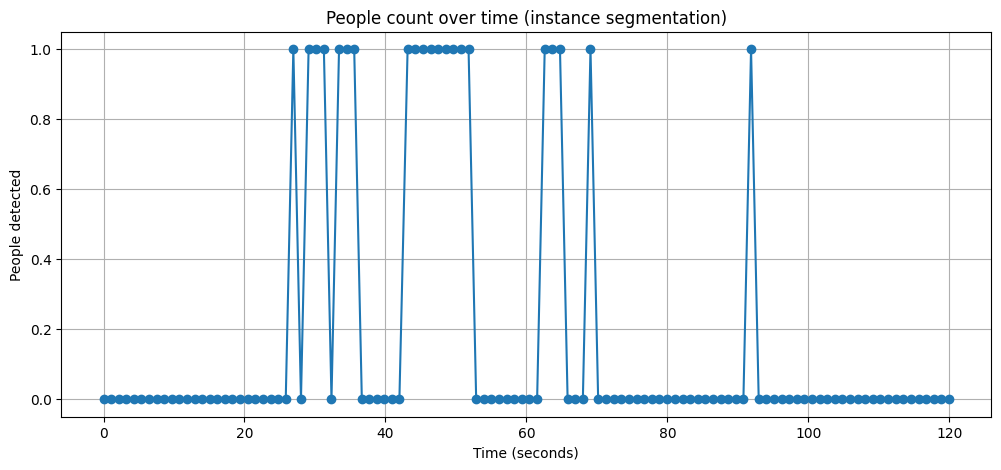

,time_s,people
0,0.002476,0
1,1.086591,0
2,2.174111,0
3,3.248242,0
4,4.299961,0
...,...,...
107,115.639180,0
108,116.722225,0
109,117.802861,0
110,118.884585,0


In [1]:
import sys
!{sys.executable} -m pip install ultralytics opencv-python-headless matplotlib pandas

from ultralytics import YOLO
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import time


# yolov8 instance segmentation model
model = YOLO("yolov8n-seg.pt")  # segmentation model

# test stream
STREAM_URL = "https://test-streams.mux.dev/test_001/stream.m3u8"

# output dir
OUTPUT_DIR = Path("../data/outputs/outputsv3")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_FPS = 1
MAX_RUNTIME = 120  # seconds maximum to run

cap = cv2.VideoCapture(STREAM_URL)

if not cap.isOpened():
    raise Exception("Video cannot be opened")

print("Stream started")

records = []
saved_index = 0
start_time = time.time()

try:
    while True:
        ret, frame = cap.read()

        if not ret or frame is None:
            print("No frame received, retrying...")
            time.sleep(1)
            continue

        elapsed = time.time() - start_time
        if elapsed > MAX_RUNTIME:
            print("Max runtime reached")
            break

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


        # yolo inference
        result = model.predict(
            frame_rgb,
            imgsz=640,
            conf=0.25,
            verbose=False
        )

        annotated = frame_rgb.copy()
        people_count = 0

        if result[0].boxes is not None and result[0].masks is not None:
            boxes = result[0].boxes
            masks = result[0].masks.data.cpu().numpy()
            classes = boxes.cls.cpu().numpy().astype(int)

            # filter persons (class 0)
            person_indices = np.where(classes == 0)[0]
            people_count = len(person_indices)

            for i in person_indices:
                mask = masks[i]

                # resize mask to image size
                mask = cv2.resize(
                    mask,
                    (frame_rgb.shape[1], frame_rgb.shape[0])
                )

                color = np.array([0, 255, 0], dtype=np.uint8)
                annotated[mask > 0.5] = (
                    annotated[mask > 0.5] * 0.5 + color * 0.5
                ).astype(np.uint8)

        print(f"People detected: {people_count}")


        # save frame
        out_path = OUTPUT_DIR / f"frame_{saved_index:04d}.jpg"
        cv2.imwrite(
            str(out_path),
            cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR)
        )


        # log data
        records.append({
            "time_s": elapsed,
            "people": people_count
        })

        saved_index += 1
        time.sleep(1 / TARGET_FPS)

except KeyboardInterrupt:
    print("Manually stopped")

finally:
    cap.release()

# visualization
if len(records) == 0:
    print("No data captured")
else:
    df_stream = pd.DataFrame(records)

    VIS_DIR = Path("../visualization/graphs")
    VIS_DIR.mkdir(parents=True, exist_ok=True)

    plt.figure(figsize=(12, 5))
    plt.plot(
        df_stream["time_s"],
        df_stream["people"],
        marker="o"
    )
    plt.xlabel("Time (seconds)")
    plt.ylabel("People detected")
    plt.title("People count over time (instance segmentation)")
    plt.grid(True)

    visual_path = VIS_DIR / "count_forecast_v3.png"
    plt.savefig(visual_path, bbox_inches="tight")
    print(f"Visualization saved in: {visual_path.resolve()}")

    plt.show()

df_stream